Setup and Imports

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
os.makedirs("exported_charts", exist_ok=True)


if os.path.exists('bluestock_mf.db'):
    db_path = 'bluestock_mf.db'
elif os.path.exists('../bluestock_mf.db'):
    db_path = '../bluestock_mf.db'
else:
    raise FileNotFoundError("Could not find bluestock_mf.db! Please check your folder structure.")

print(f"✅ Found database at: {db_path}")


conn = sqlite3.connect(db_path)


cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"✅ Tables inside this database: {[t[0] for t in tables]}")


if os.path.exists('data/processed'):
    PROCESSED_DIR = 'data/processed'
else:
    PROCESSED_DIR = '../data/processed'

print("Environment Setup Complete. Ready for EDA!")

C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


✅ Found database at: ../bluestock_mf.db
✅ Tables inside this database: ['dim_fund', 'fact_nav', 'fact_performance', 'fact_transactions', 'fact_portfolio_holdings']
Environment Setup Complete. Ready for EDA!


Task 1 - NAV Trend Analysis (Plotly)

In [ ]:

query = """
    SELECT n.nav_date, n.nav, f.scheme_name 
    FROM fact_nav n
    JOIN dim_fund f ON n.amfi_code = f.amfi_code
"""
df_nav = pd.read_sql(query, conn)
df_nav['nav_date'] = pd.to_datetime(df_nav['nav_date'])


fig1 = px.line(df_nav, x='nav_date', y='nav', color='scheme_name', 
               title='Daily NAV Trend Analysis (2022-2026)',
               labels={'nav_date': 'Date', 'nav': 'Net Asset Value (INR)'})


fig1.add_vrect(x0="2023-03-01", x1="2023-12-31", fillcolor="green", opacity=0.1, 
               layer="below", line_width=0, annotation_text="2023 Bull Run")


fig1.add_vrect(x0="2024-05-01", x1="2024-07-31", fillcolor="red", opacity=0.1, 
               layer="below", line_width=0, annotation_text="2024 Market Correction")

fig1.update_layout(showlegend=False) 
fig1.write_html("exported_charts/01_nav_trend.html")
fig1.show()

Task 2 - AUM Growth by Fund House (Seaborn)

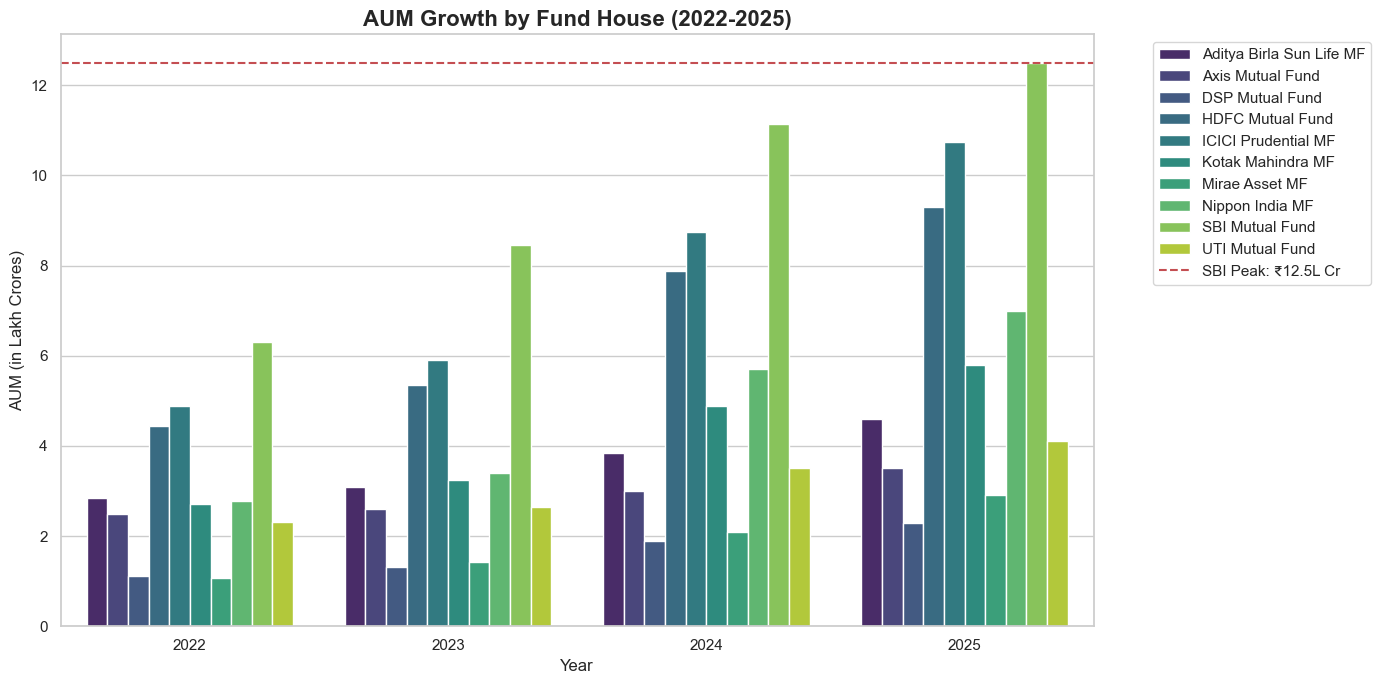

In [ ]:

df_aum = pd.read_csv(os.path.join(PROCESSED_DIR, "clean_aum_by_fund_house.csv"))
df_aum['year'] = pd.to_datetime(df_aum['date']).dt.year


aum_yearly = df_aum.groupby(['year', 'fund_house'])['aum_lakh_crore'].max().reset_index()

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=aum_yearly, x='year', y='aum_lakh_crore', hue='fund_house', palette="viridis")

plt.title('AUM Growth by Fund House (2022-2025)', fontsize=16, fontweight='bold')
plt.ylabel('AUM (in Lakh Crores)', fontsize=12)
plt.xlabel('Year', fontsize=12)


plt.axhline(y=12.5, color='r', linestyle='--', label='SBI Peak: ₹12.5L Cr')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('exported_charts/02_aum_growth.png')
plt.show()

Task 3 - Monthly SIP Inflows (Plotly)

In [ ]:
df_sip = pd.read_csv(os.path.join(PROCESSED_DIR, "clean_monthly_sip_inflows.csv"))

fig3 = px.line(df_sip, x='month', y='sip_inflow_crore', markers=True,
               title='Monthly SIP Inflow Trend (2022-2025)',
               labels={'month': 'Month', 'sip_inflow_crore': 'SIP Inflow (₹ Crores)'})

fig3.update_traces(line_color='#2c3e50', marker=dict(size=8, color='#e74c3c'))


fig3.add_annotation(x="2025-12", y=31002,
                    text="All-Time High: ₹31,002 Cr",
                    showarrow=True, arrowhead=1, ax=-50, ay=-40,
                    font=dict(size=12, color="white"), bgcolor="green")

fig3.write_html("exported_charts/03_sip_inflows.html")
fig3.show()

Task 4 - Category Inflow Heatmap (Seaborn)

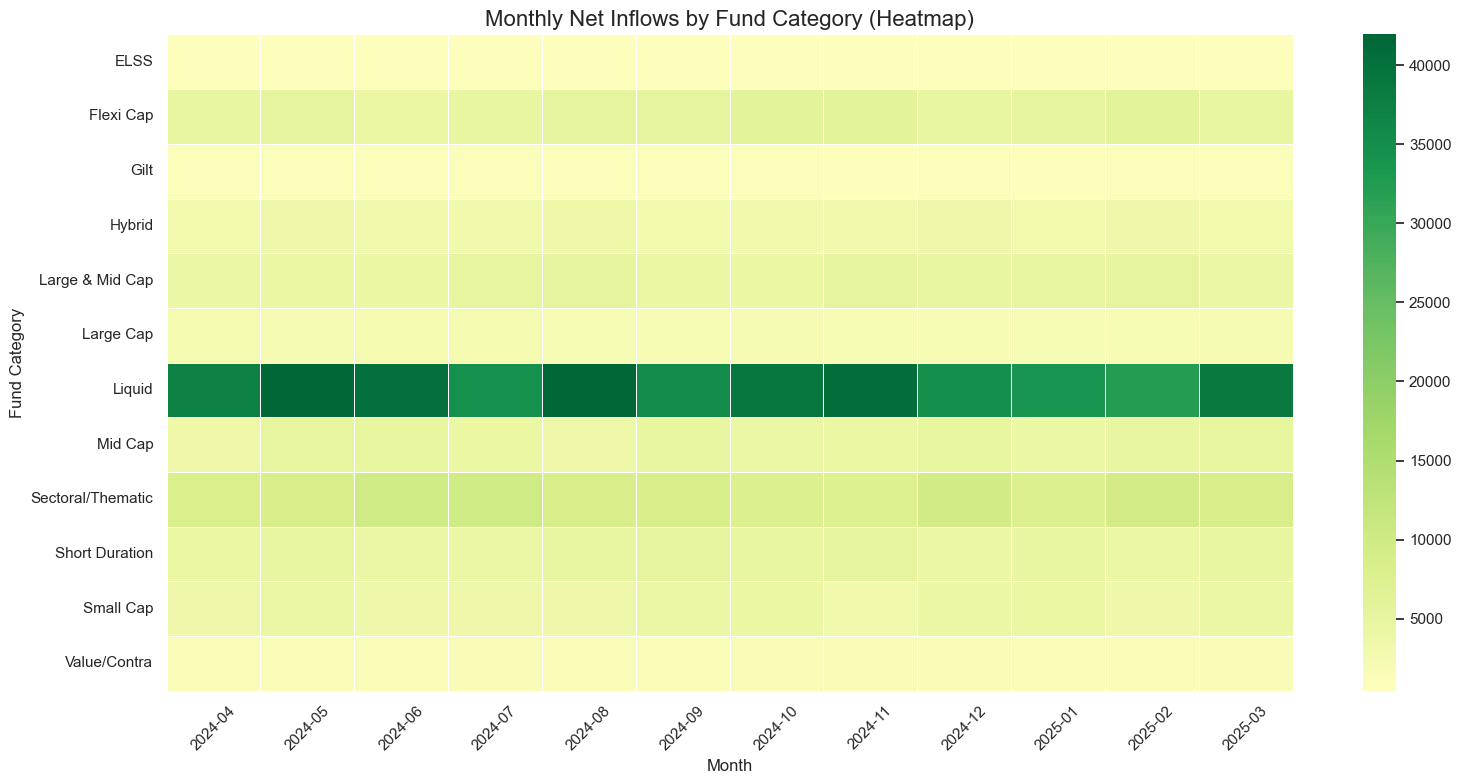

In [ ]:
df_cat = pd.read_csv(os.path.join(PROCESSED_DIR, "clean_category_inflows.csv"))


pivot_cat = df_cat.pivot(index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_cat, cmap='RdYlGn', center=0, annot=False, fmt=".0f", linewidths=.5)
plt.title('Monthly Net Inflows by Fund Category (Heatmap)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('exported_charts/04_category_heatmap.png')
plt.show()

Task 5 & 6 - Investor Demographics & Geo Distribution

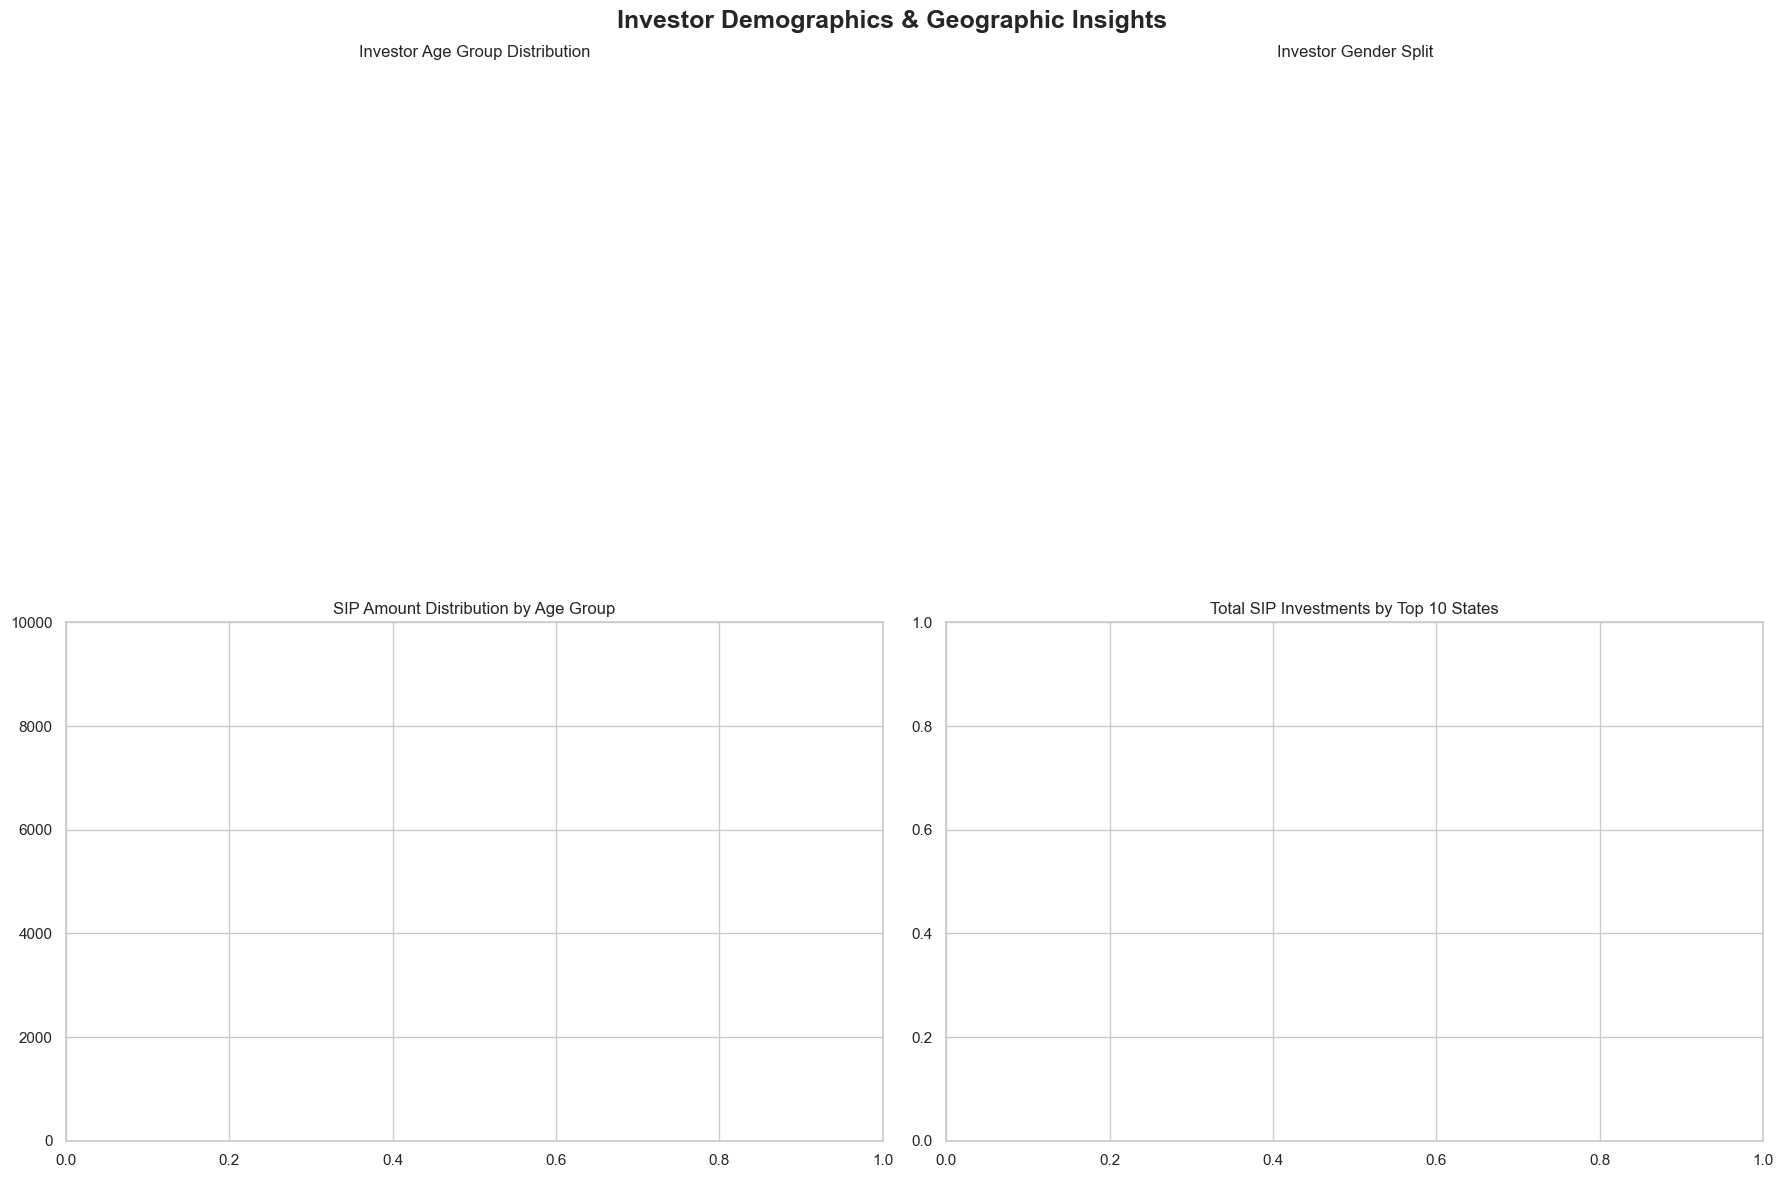

In [ ]:
query_tx = "SELECT * FROM fact_transactions WHERE transaction_type = 'SIP'"
df_tx = pd.read_sql(query_tx, conn)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Investor Demographics & Geographic Insights', fontsize=18, fontweight='bold')

# 1. Age Group Distribution (Pie)
age_counts = df_tx['age_group'].value_counts()
axes[0, 0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[0, 0].set_title('Investor Age Group Distribution')

# 2. Gender Split (Pie)
gender_counts = df_tx['gender'].value_counts()
axes[0, 1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#3498db', '#e74c3c'])
axes[0, 1].set_title('Investor Gender Split')

# 3. Boxplot: SIP Amount by Age
sns.boxplot(ax=axes[1, 0], data=df_tx, x='age_group', y='amount_inr', palette='Set2')
axes[1, 0].set_title('SIP Amount Distribution by Age Group')
axes[1, 0].set_ylim(0, 10000) # Capping outliers for better view

# 4. Horizontal Bar: SIP by State
state_sip = df_tx.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(10)
sns.barplot(ax=axes[1, 1], x=state_sip.values, y=state_sip.index, palette='magma')
axes[1, 1].set_title('Total SIP Investments by Top 10 States')

plt.tight_layout()
plt.savefig('exported_charts/05_demographics_geo.png')
plt.show()

Task 8 - NAV Return Correlation Matrix

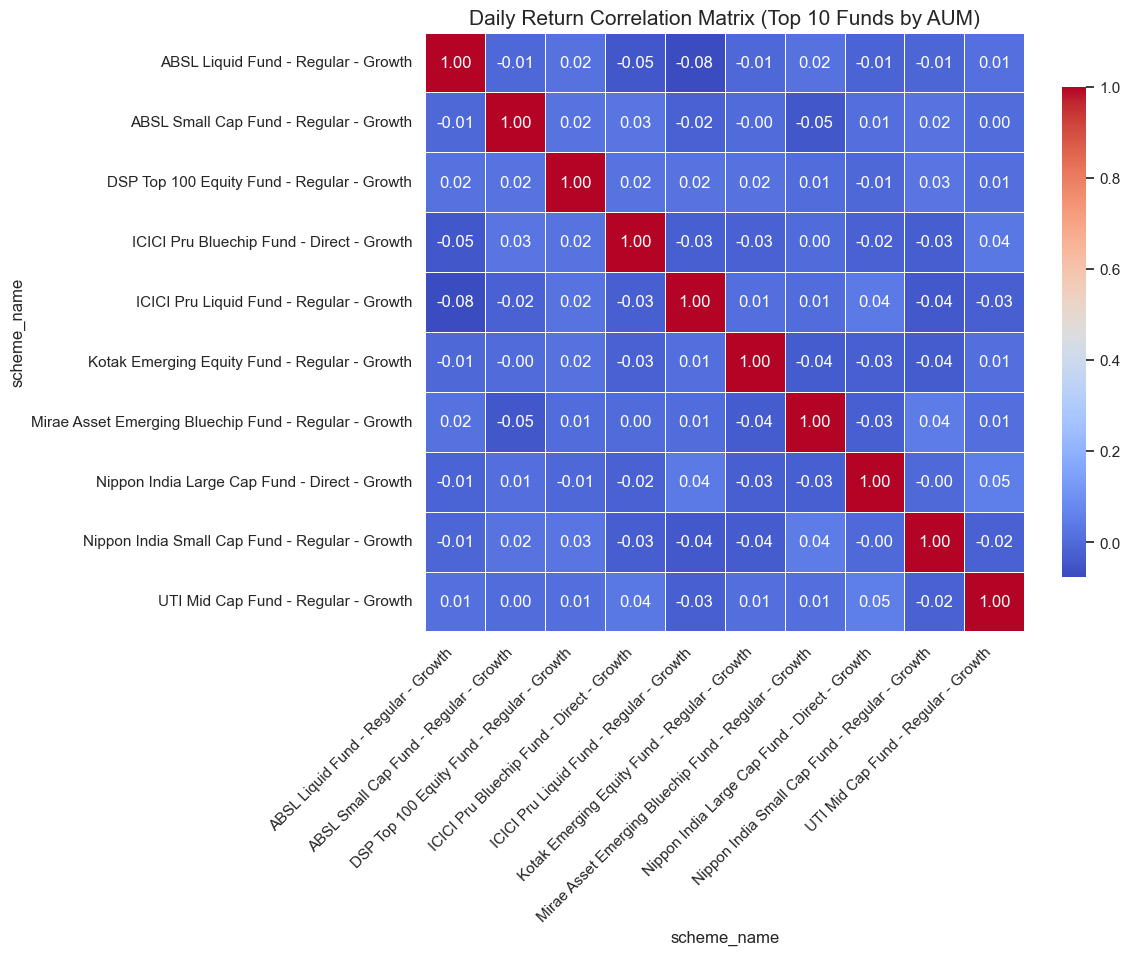

In [ ]:

top_funds_query = "SELECT amfi_code, scheme_name FROM fact_performance ORDER BY aum_crore DESC LIMIT 10"
top_funds = pd.read_sql(top_funds_query, conn)
top_amfi = tuple(top_funds['amfi_code'].tolist())


returns_query = f"SELECT nav_date, amfi_code, nav FROM fact_nav WHERE amfi_code IN {top_amfi}"
df_ret = pd.read_sql(returns_query, conn)


df_ret = df_ret.merge(top_funds, on='amfi_code')


df_ret['nav_date'] = pd.to_datetime(df_ret['nav_date'])
df_ret = df_ret.sort_values(['scheme_name', 'nav_date'])
df_ret['daily_return'] = df_ret.groupby('scheme_name')['nav'].pct_change()


pivot_ret = df_ret.pivot(index='nav_date', columns='scheme_name', values='daily_return').dropna()
corr_matrix = pivot_ret.corr()


plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .75})
plt.title('Daily Return Correlation Matrix (Top 10 Funds by AUM)', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('exported_charts/08_correlation_matrix.png')
plt.show()

Task 9 - Sector Allocation Donut Chart

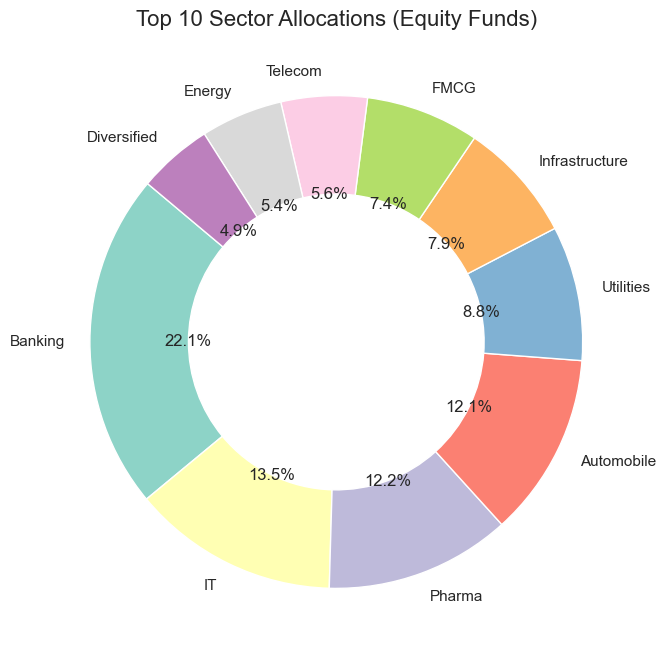

In [ ]:

port_query = "SELECT sector, market_value_cr FROM fact_portfolio_holdings"
df_port = pd.read_sql(port_query, conn)


sector_agg = df_port.groupby('sector')['market_value_cr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 8))
plt.pie(sector_agg, labels=sector_agg.index, autopct='%1.1f%%', startangle=140, 
        wedgeprops=dict(width=0.4, edgecolor='w'), colors=sns.color_palette("Set3"))
plt.title('Top 10 Sector Allocations (Equity Funds)', fontsize=16)
plt.savefig('exported_charts/09_sector_donut.png')
plt.show()

Task 7 - Folio Count Growth (Matplotlib/Seaborn)

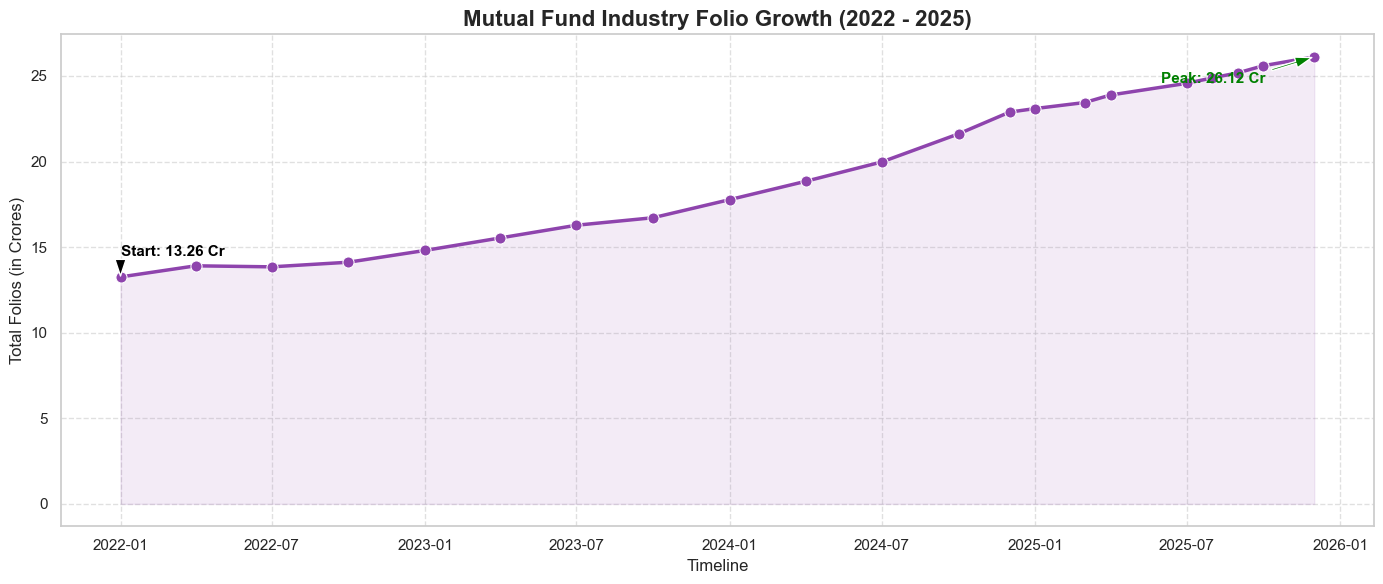

In [ ]:
df_folios = pd.read_csv(os.path.join(PROCESSED_DIR, "clean_industry_folio_count.csv"))
df_folios['month'] = pd.to_datetime(df_folios['month'])

plt.figure(figsize=(14, 6))


sns.lineplot(data=df_folios, x='month', y='total_folios_crore', 
             marker='o', color='#8e44ad', linewidth=2.5, markersize=8)

plt.title('Mutual Fund Industry Folio Growth (2022 - 2025)', fontsize=16, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Folios (in Crores)', fontsize=12)


start_date = pd.to_datetime("2022-01-01")
plt.annotate('Start: 13.26 Cr', 
             xy=(start_date, 13.26), 
             xytext=(start_date, 14.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, fontweight='bold', color='black')


end_date = df_folios['month'].max()
end_val = df_folios['total_folios_crore'].max()
plt.annotate(f'Peak: {end_val} Cr', 
             xy=(end_date, end_val), 
             xytext=(end_date - pd.DateOffset(months=6), end_val - 1.5),
             arrowprops=dict(facecolor='green', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, fontweight='bold', color='green')


plt.fill_between(df_folios['month'], df_folios['total_folios_crore'], color='#8e44ad', alpha=0.1)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


plt.savefig('exported_charts/07_folio_growth.png')
plt.show()

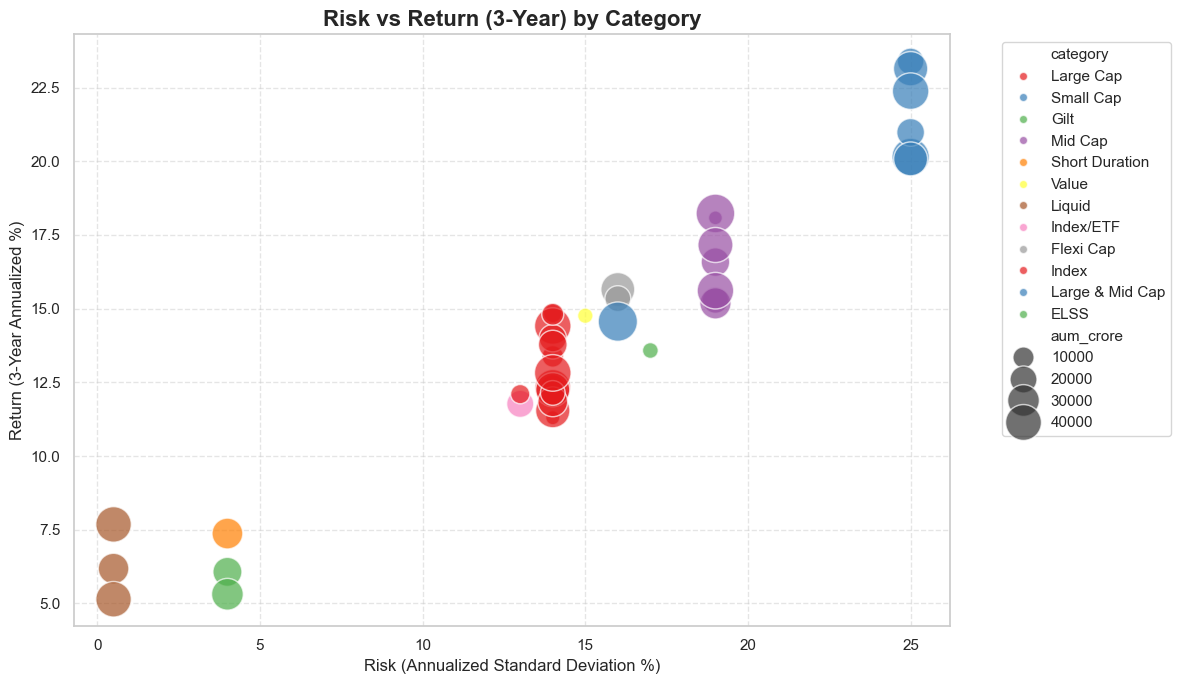

C:\Users\dell\AppData\Local\Temp\ipykernel_11724\2080236234.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_perf, x='category', y='expense_ratio_pct', palette='Pastel1', inner="quartile")


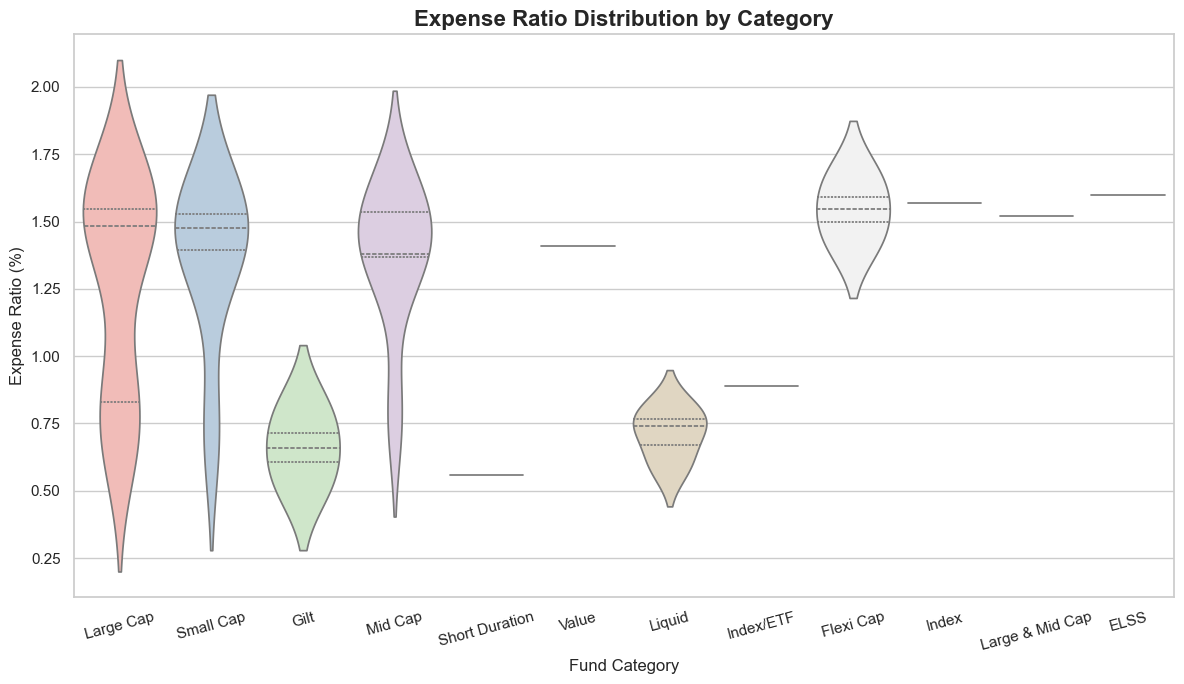

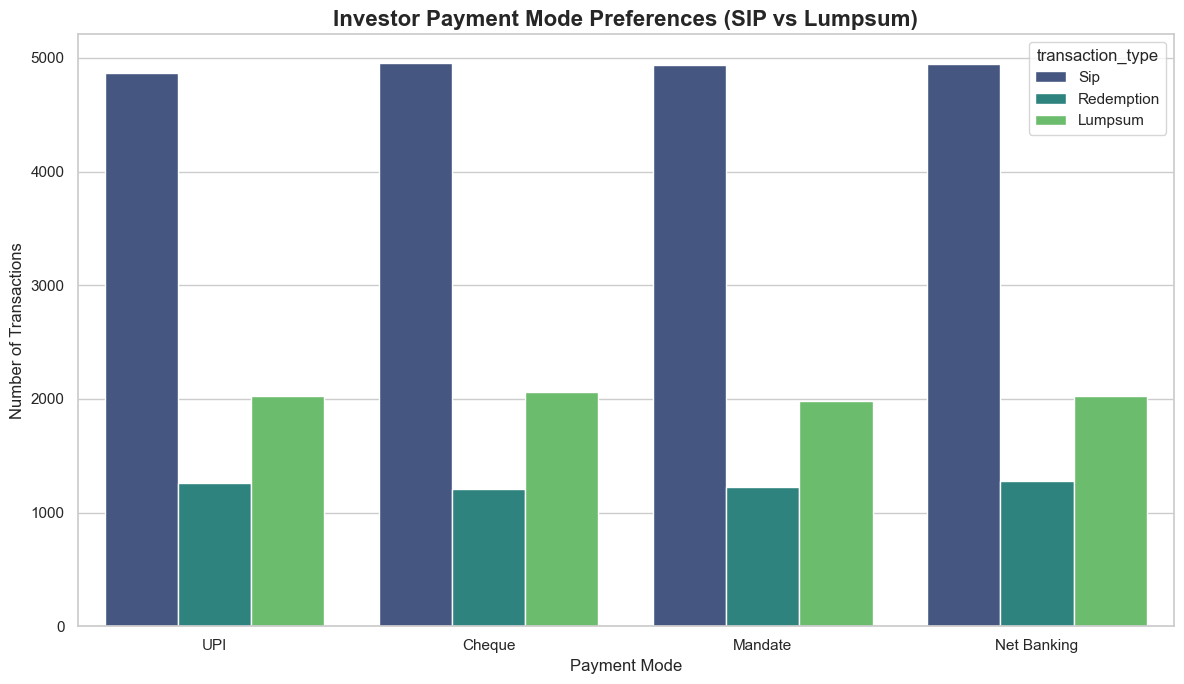

<Figure size 1200x700 with 0 Axes>

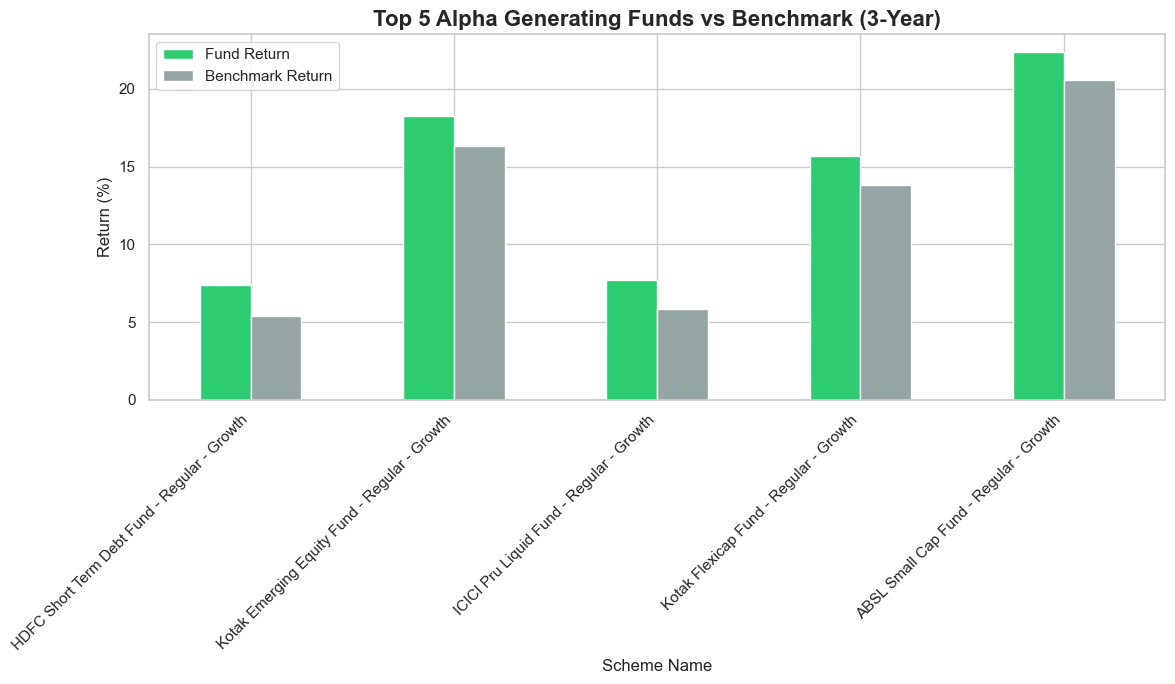

In [ ]:

df_perf = pd.read_sql("SELECT * FROM fact_performance", conn)
df_tx_all = pd.read_sql("SELECT * FROM fact_transactions", conn)

# ---------------------------------------------------------
# Chart 12: Risk vs. Return Scatter Plot
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_perf, x='std_dev_ann_pct', y='return_3yr_pct', 
                hue='category', size='aum_crore', sizes=(100, 800), 
                alpha=0.7, palette='Set1')
plt.title('Risk vs Return (3-Year) by Category', fontsize=16, fontweight='bold')
plt.xlabel('Risk (Annualized Standard Deviation %)', fontsize=12)
plt.ylabel('Return (3-Year Annualized %)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('exported_charts/10_risk_return_scatter.png')
plt.show()

# ---------------------------------------------------------
# Chart 13: Expense Ratio Distribution (Violin Plot)
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))
sns.violinplot(data=df_perf, x='category', y='expense_ratio_pct', palette='Pastel1', inner="quartile")
plt.title('Expense Ratio Distribution by Category', fontsize=16, fontweight='bold')
plt.xlabel('Fund Category', fontsize=12)
plt.ylabel('Expense Ratio (%)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('exported_charts/11_expense_ratio_violin.png')
plt.show()

# ---------------------------------------------------------
# Chart 14: Payment Mode Preferences (Countplot)
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))
sns.countplot(data=df_tx_all, x='payment_mode', hue='transaction_type', palette='viridis')
plt.title('Investor Payment Mode Preferences (SIP vs Lumpsum)', fontsize=16, fontweight='bold')
plt.xlabel('Payment Mode', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.tight_layout()
plt.savefig('exported_charts/12_payment_mode_countplot.png')
plt.show()

# ---------------------------------------------------------
# Chart 15: Alpha Generation - Fund vs Benchmark Returns
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))
top_5_alpha = df_perf.nlargest(5, 'alpha')[['scheme_name', 'return_3yr_pct', 'benchmark_3yr_pct']]

ax = top_5_alpha.set_index('scheme_name').plot(kind='bar', figsize=(12, 7), color=['#2ecc71', '#95a5a6'])
plt.title('Top 5 Alpha Generating Funds vs Benchmark (3-Year)', fontsize=16, fontweight='bold')
plt.xlabel('Scheme Name', fontsize=12)
plt.ylabel('Return (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(['Fund Return', 'Benchmark Return'])
plt.tight_layout()
plt.savefig('exported_charts/13_alpha_generation_bar.png')
plt.show()

# ---------------------------------------------------------
# Chart 16: Interactive Market Share Treemap (Plotly)
# ---------------------------------------------------------
fig_tree = px.treemap(df_perf, 
                      path=[px.Constant("Mutual Fund Industry"), 'fund_house', 'category', 'scheme_name'], 
                      values='aum_crore',
                      color='return_1yr_pct',
                      color_continuous_scale='RdYlGn',
                      title='AUM Market Share Treemap (Color coded by 1-Year Return)')
fig_tree.update_layout(width=1000, height=700)
fig_tree.write_html("exported_charts/14_aum_treemap.html")
fig_tree.show()